# Supplementary Figure S33: `s33_robadvctl_controls`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_robadvctl_controls.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

The previous figure showed that the automatically selected synthesis regularization tracks control fidelity. This one asks whether the adversarially trained models' control advantage survives once those hyperparameters are accounted for. A single joint linear model with model, site, augmentation-noise and spectral-decay terms is fit to each control outcome, and the part attributed to the two knobs is subtracted, leaving model and site structure in place. Panels A and B show the adjusted outcomes per model; panel C compares the raw adversarial-versus-conventional gap with the adjusted gap from an ANCOVA.

## What the script says about itself

Supp fig (robadvctl_controls) - control outcomes after regressing out the effect of the synthesis hyperparameters.

The synthesis regularization knobs (augmentation NOISE + spectral-decay ALPHA, selected per site-model by an automated procedure) are regressed out of the control outcomes, using coefficients from the JOINT model `outcome ~ C(model) + noise + decay + C(site)` so model structure is never absorbed into the hp slopes; site variance stays in the display.

a,b Control r / control slope with hp regressed out, by model (per-model swarms + means, models sorted by residual mean).

- **(c)** Summary: raw adv-vs-conventional gap (site-fixed-effects Delta among the 9 trained models, p = within-site paired Wilcoxon over 25 sites) vs the hp-ADJUSTED gap (ANCOVA `outcome ~ adv + noise + decay + C(site)`, site-clustered p). Untrained is shown in a,b but never enters the family tests.

Reads loader.control_table() + <preprocessed_data>/sup_hyperparam_hp_tuning_selected.csv (built by scripts/preprocessing/build_hp_tuning_cache.py).

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`COVARS` names the two regularization knobs regressed out. `OUTCOMES` lists the two control measures, `ROBUST` the two adversarially trained models, and `UNTR` the untrained baseline, which is shown in the per-model panels but never enters the family tests. `C_ADJ` is the orange used for adjusted bars.

In [2]:
import os

import numpy as np

import pandas as pd

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

from pnc import paths

from pnc.utils import (apply_figure_style, FONT_FAMILY, FIG_FACECOLOR, save_fig, MM,
                       WIDTH_2COL_MM, MODEL_SHORT_NAMES, get_model_color)

from pnc.manifest import fig as _fig, output_name

from pnc.preproc import loader as L

from pnc.famstats import adv_gap, partial_residuals, stars as _sig_stars

apply_figure_style()

STEM = output_name('robadvctl_controls')

UNTR = 'AlexNet_training_seed_01'

SHORT = dict(MODEL_SHORT_NAMES); SHORT[UNTR] = 'Untrained'



ROBUST = {'clipag_vitb32', 'resnet50_robust'}

PREPROC_DATA = str(paths.preprocessed_data())

HP_CSV = os.path.join(PREPROC_DATA, 'sup_hyperparam_hp_tuning_selected.csv')

HP_HINT = 'python scripts/preprocessing/build_hp_tuning_cache.py'

FS_TITLE, FS_AX, FS_TICK, FS_ANNOT, FS_LETTER = 7, 6.5, 5.5, 5, 10

C_ADJ = '#E1812C'

COVARS = ('noise', 'decay')

OUTCOMES = [('control_r', 'Control $r$'), ('control_slope', 'Control slope')]

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

`load` prepares the table with residualized outcomes; `per_model_panel` and `summary_panel` each draw one kind of panel. The statistics come from the shared `pnc.famstats` helpers `partial_residuals` and `adv_gap`.

### `load()`

Merges the control table with the hyperparameter cache and, for each outcome, adds a column of partial residuals from the joint model with the knob effects removed but model and site effects kept.

In [3]:
def load():
    ct = L.control_table()
    hp = pd.read_csv(paths.require(HP_CSV, hint=HP_HINT))
    m = ct.merge(hp, left_on=['monkey', 'model', 'unit'], right_on=['monkey', 'model', 'channel'])
    m['robust'] = m['robust'].astype(int)
    m['unit'] = m['unit'].astype(int)
    for y, _ in OUTCOMES:
        # joint-model partial residuals: hp effects removed, model + site structure kept
        m[y + '_res'] = partial_residuals(m, y, COVARS, keep='model', remove_site=False)
    return m

### `_spines(ax)`

In [4]:
def _spines(ax):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

### `per_model_panel(ax, m, y, ylabel)`

For one outcome, orders models by their adjusted mean and draws each model's site-model residuals as a jittered swarm. Two bars sit on each column: gray for the raw mean and black for the adjusted mean, so the shift from adjustment is visible. Adversarially trained model names are bold.

In [5]:
def per_model_panel(ax, m, y, ylabel):
    col = y + '_res'
    order = m.dropna(subset=[col]).groupby('model')[col].mean().sort_values().index.tolist()
    rng = np.random.default_rng(0)
    for xi, mdl in enumerate(order):
        d = m[m.model == mdl].dropna(subset=[col])
        ax.scatter(xi + rng.uniform(-0.28, 0.28, len(d)), d[col], s=6, color=get_model_color(mdl),
                   alpha=0.85, edgecolors='white', linewidths=0.2, zorder=4)
        ax.plot([xi - 0.34, xi + 0.34], [d[y].mean()] * 2, color='#b0b0b0', lw=1.2, zorder=5)
        ax.plot([xi - 0.34, xi + 0.34], [d[col].mean()] * 2, color='black', lw=1.2, zorder=6)
    ax.axhline(0, color='#888', lw=0.8, ls='--', zorder=1)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([SHORT[mm] for mm in order], rotation=45, ha='right', fontsize=FS_TICK)
    for t, mm in zip(ax.get_xticklabels(), order):
        t.set_color(get_model_color(mm)); t.set_fontweight('bold' if mm in ROBUST else 'normal')
    ax.set_ylabel(ylabel + ', hp regressed out', fontsize=FS_AX)
    ax.set_title(ylabel + ' residuals by model', fontsize=FS_TITLE, fontweight='bold',
                 fontfamily=FONT_FAMILY, pad=4)
    ax.tick_params(axis='y', labelsize=FS_TICK); _spines(ax)

### `summary_panel(ax, m)`

Raw (site-FE, within-site Wilcoxon) vs hp-adjusted (ANCOVA, site-clustered p), among the 9 trained models.

For each outcome, draws two bars: the raw adversarial-minus-conventional gap among the nine trained models (p from a within-site paired Wilcoxon over the 25 sites) and the hp-adjusted gap (p from an ANCOVA with site fixed effects and site-clustered errors). Significance stars sit above each bar.

In [6]:
def summary_panel(ax, m):
    """Raw (site-FE, within-site Wilcoxon) vs hp-adjusted (ANCOVA, site-clustered p),
    among the 9 trained models."""
    x = np.arange(len(OUTCOMES)); w = 0.34
    for k, (y, _) in enumerate(OUTCOMES):
        raw = adv_gap(m, y)
        adj = adv_gap(m, y, covariates=COVARS)
        for j, (g, c, lab) in enumerate([(raw, '#CCCCCC', 'Raw'),
                                         (adj, C_ADJ, 'hp-adjusted')]):
            xx = k + (j - 0.5) * w
            ax.bar(xx, g['delta'], w * 0.9, color=c, edgecolor='black', linewidth=0.4,
                   label=(lab if k == 0 else None))
            ax.text(xx, g['delta'] + 0.008, _sig_stars(g['p']),
                    ha='center', va='bottom', fontsize=FS_TICK)
    ax.set_xticks(x); ax.set_xticklabels([lab for _, lab in OUTCOMES], fontsize=FS_TICK)
    ax.set_ylabel(r'(Adv. $-$ conventional training)', fontsize=FS_AX)
    ax.set_title('Summary: baseline vs. hp-adjusted', fontsize=FS_TITLE, fontweight='bold',
                 fontfamily=FONT_FAMILY, pad=4)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.30)
    ax.legend(fontsize=FS_ANNOT, frameon=False, loc='upper center', ncol=2, columnspacing=1.0,
              labelspacing=0.3, handlelength=1.0, handletextpad=0.35, bbox_to_anchor=(0.5, 1.02))
    ax.tick_params(labelsize=FS_TICK); _spines(ax)

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

A single row of three panels, the two per-model swarms wider than the summary. The table is loaded, panels drawn, then letters, title, subtitle and a legend for the two mean bars are added after a draw pass.

In [7]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Loads the merged table with residualized outcomes.

In [8]:
m = load()

**Step 2**

Creates the figure and grid and fills the control `r` panel, the control slope panel, and the summary.

In [9]:
fig = plt.figure(figsize=(WIDTH_2COL_MM * MM, 72 * MM), facecolor=FIG_FACECOLOR)
gs = GridSpec(1, 3, figure=fig, left=0.07, right=0.985, top=0.775, bottom=0.30,
              wspace=0.42, width_ratios=[1.3, 1.3, 0.85])
letters = []
a = fig.add_subplot(gs[0, 0]); per_model_panel(a, m, 'control_r', 'Control $r$'); letters.append(a)
a = fig.add_subplot(gs[0, 1]); per_model_panel(a, m, 'control_slope', 'Control slope'); letters.append(a)
a = fig.add_subplot(gs[0, 2]); summary_panel(a, m); letters.append(a)

**Step 3**

Places letters, the title and a subtitle noting the collinearity of the two knobs, adds a legend distinguishing raw from adjusted means, and prints the raw and adjusted gaps with their p-values to the console.

In [10]:
fig.canvas.draw()
for ax, L_ in zip(letters, 'abc'):
    bb = ax.get_position()
    dx = 0.050 if L_ == 'c' else 0.032
    fig.text(bb.x0 - dx, bb.y1 + 0.016, L_, ha='left', va='bottom', fontsize=FS_LETTER,
             fontweight='bold', fontfamily=FONT_FAMILY)
fig.text(0.5, 0.965, 'Control outcomes after regressing out the effect of synthesis hyperparameters',
         ha='center', va='top', fontsize=FS_TITLE, fontweight='bold', fontfamily=FONT_FAMILY)
fig.text(0.5, 0.925, 'n = 250 site-models (10 models $\\times$ 5 channels $\\times$ 5 monkeys); '
         'noise & decay collinear ($r$=0.98)',
         ha='center', va='top', fontsize=FS_TICK, fontfamily=FONT_FAMILY, color='#555')
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0], [0], color='#b0b0b0', lw=1.4, label='raw mean'),
                    Line2D([0], [0], color='black', lw=1.4, label='mean, hp regressed out')],
           fontsize=FS_ANNOT, frameon=False, ncol=2, loc='upper center',
           bbox_to_anchor=(0.389, 0.898), handlelength=1.2, handletextpad=0.4, columnspacing=1.4)

# console: raw vs adjusted gaps
for y, lab in OUTCOMES:
    raw = adv_gap(m, y); adj = adv_gap(m, y, covariates=COVARS)
    print(f'{lab}: raw D={raw["delta"]:+.3f} (p={raw["p"]:.2g}, {raw["test"]}) | '
          f'hp-adjusted D={adj["delta"]:+.3f} (p={adj["p"]:.2g}, {adj["test"]})')

Control $r$: raw D=+0.245 (p=1.2e-07, within-site paired Wilcoxon) | hp-adjusted D=+0.240 (p=6.8e-13, site-FE ANCOVA, site-clustered)
Control slope: raw D=+0.250 (p=6e-08, within-site paired Wilcoxon) | hp-adjusted D=+0.233 (p=3.4e-12, site-FE ANCOVA, site-clustered)


**Step 4**

Saves and closes the figure; `png` receives the path.

In [11]:
path = save_fig(fig, os.path.join(out_dir, STEM))
plt.close(fig)
print('Saved ->', path)
png = path

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s33_robadvctl_controls.png


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s33_robadvctl_controls.png` in the output directory).

Compare the gray and black bars within each column of panels A and B: adjustment moves the means a little but leaves the two bold models at the top. In panel C both the raw and adjusted gaps should be positive and starred, which is the evidence that the advantage is not an artifact of regularization settings.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s33_robadvctl_controls.png


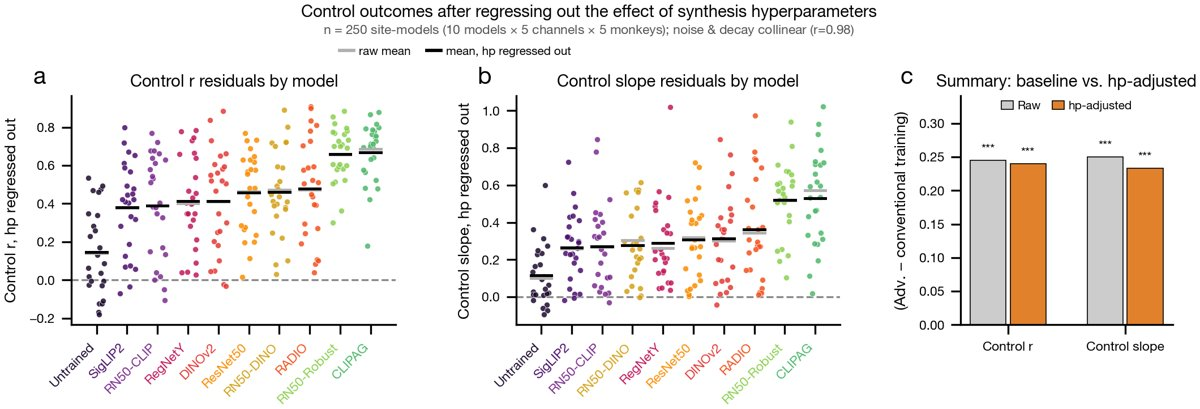

In [12]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S33. Control outcomes after regressing out the effect of synthesis hyperparameters.** This analysis examines whether the adversarially trained models' control advantage is related to the synthesis hyperparameters (hp) that were involved in generating the accentuations, i.e., the two regularization knobs, augmentation noise and spectral decay (Supplementary Fig. S6). Across all $n = 250$ site-models ($10$ models $\times$ $5$ sites $\times$ $5$ macaques), a single OLS model, $\mathrm{outcome} \sim \mathrm{model} + \mathrm{noise} + \mathrm{decay} + \mathrm{site}$, was fit for each control outcome, and the part of the outcome attributed to the two knob terms was subtracted. The knobs rise together along the regularization ladder and are nearly collinear ($r = 0.98$), so their individual coefficients are not meaningful; only their combined contribution is used, and including both removes as much hp-related variance as possible. (A, B) Control $r$ (A) and control slope (B) with hp regressed out, one dot per site-model, colored by model; black bars, hp-adjusted model means; gray bars, raw means; dashed line at zero; models ordered by adjusted mean, adversarially trained models in bold. (C) We assess the gap in control outcomes between the adversarially trained and conventionally trained model families, comparing raw and hp-adjusted scenarios (raw $p$ from a within-site paired Wilcoxon over the $25$ sites; hp-adjusted $p$ from an ANCOVA with site fixed effects and site-clustered errors; $\ast\ast\ast$ $p < 10^{-3}$).